Dataset loading and Model Training

In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('/content/feature_time_48k_2048_load_1.csv')

In [2]:
dataset.head()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


In [3]:
dataset = dataset.drop(['max', 'min','mean'], axis=1)

In [4]:
dataset['fault'].unique()

array(['Ball_007_1', 'Ball_014_1', 'Ball_021_1', 'IR_007_1', 'IR_014_1',
       'IR_021_1', 'OR_007_6_1', 'OR_014_6_1', 'OR_021_6_1', 'Normal_1'],
      dtype=object)

In [5]:
dataset_train = dataset[dataset['fault'] == "Normal_1"]

In [6]:
dataset_fault = dataset[dataset['fault'] != "Normal_1"]

In [7]:
X = dataset_train.drop(['fault'], axis=1)
y = dataset_train['fault']

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X_train_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [11]:
X_all = dataset.drop(['fault'], axis=1)
X_all_scaled = scaler.transform(X_all)

anomaly_scores = model.decision_function(X_all_scaled)
dataset['anomaly_score'] = anomaly_scores

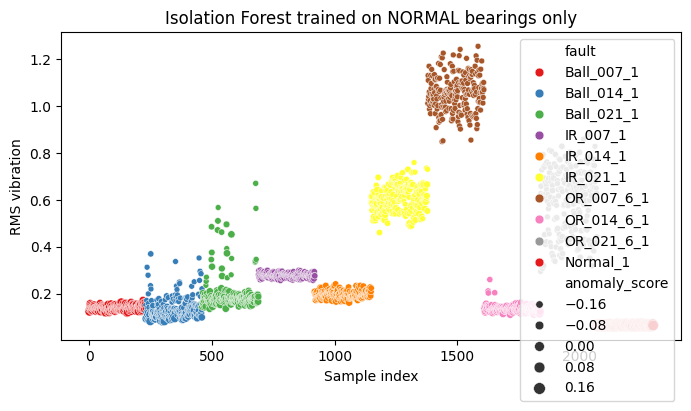

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.scatterplot(
    x=dataset.index,
    y=dataset['rms'],
    hue=dataset['fault'],
    size=dataset['anomaly_score'],
    palette='Set1',
    s=40
)
plt.title("Isolation Forest trained on NORMAL bearings only")
plt.xlabel("Sample index")
plt.ylabel("RMS vibration")
plt.show()

In [13]:
import joblib
joblib.dump(model, "bearing_iforest_final_2.joblib")
joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']

Calculating mean and std

In [14]:
X_fault = dataset_fault.drop(['fault'], axis=1)

X_fault_scaled = scaler.transform(X_fault)

In [18]:
normal_scores = model.decision_function(X_train_scaled)
fault_scores  = model.decision_function(X_fault_scaled)

print(np.mean(normal_scores), np.std(normal_scores))
print(np.mean(fault_scores),  np.std(fault_scores))

0.10539300216817271 0.048563504568900816
-0.19535152851077023 0.04034601445371281


In [19]:
baseline_mean = np.mean(normal_scores)
baseline_std  = np.std(normal_scores)

print("Baseline mean:", baseline_mean)
print("Baseline std:", baseline_std)

Baseline mean: 0.10539300216817271
Baseline std: 0.048563504568900816


In [20]:
joblib.dump((baseline_mean, baseline_std), "iforest_baseline.joblib")

['iforest_baseline.joblib']